## Task 20:  Assignment

Q1. (Preparing Features)

Load your cleaned Ford Car Dataset.

Separate the dataset into Independent Features (X) and Dependent Feature
(Y) (price).

Drop the target column from X.

Print the shape of X and Y.


In [1]:
import pandas as pd


In [7]:
df = pd.read_csv("Car_Price_Prediction.csv")

# Clean up structural index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Separate the dataset into Independent Features (X) and Dependent Feature (Y)
X = df.drop(columns=["Price"])
Y = df["Price"]

# Print the shapes of X and Y
print(f"Shape of Independent Features (X): {X.shape}")
print(f"Shape of Dependent Feature (Y):    {Y.shape}")

Shape of Independent Features (X): (1000, 7)
Shape of Dependent Feature (Y):    (1000,)


Q2. (One-Hot Encoding)

Identify all categorical columns in X.

Perform One-Hot Encoding using pd.get_dummies().

Convert the encoded data to integer type (astype(int)).

Show the first 5 rows after encoding

In [8]:
# 1. Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical Columns: {categorical_cols}")

# 2. Perform One-Hot Encoding and convert to integer type
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True).astype(int)

# 3. Show the first 5 rows after encoding
display(X_encoded.head(5))


Categorical Columns: ['Make', 'Model', 'Fuel Type', 'Transmission']


,Year,Engine Size,Mileage,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
0,2015,3,74176,0,0,1,0,1,0,0,0,0,1,1
1,2014,1,94799,0,1,0,0,0,1,0,0,1,0,0
2,2006,4,98385,1,0,0,0,1,0,0,0,1,0,1
3,2015,2,88919,0,0,1,0,1,0,0,0,1,0,0
4,2004,3,138482,0,0,1,0,0,1,0,0,0,1,0


Q3. (Feature Scaling)

Apply Standard Scaling on the numerical columns (year, mileage, tax, mpg,
engineSize).

Use StandardScaler from sklearn.preprocessing.

Show the first 5 rows of the scaled features.


In [9]:
from sklearn.preprocessing import StandardScaler

# Identify the numerical columns present in the dataset
numeric_features = ["Year", "Mileage", "Engine Size"]

# Create a copy of the encoded dataframe to retain structure
X_scaled = X_encoded.copy()

# Initialize and apply StandardScaler to the numerical columns
scaler = StandardScaler()
X_scaled[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

# Show the first 5 rows of the scaled features
display(X_scaled.head(5))


,Year,Engine Size,Mileage,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
0,0.686031,0.588022,-0.387368,0,0,1,0,1,0,0,0,0,1,1
1,0.526933,-1.336765,-0.040282,0,1,0,0,0,1,0,0,1,0,0
2,-0.745852,1.550416,0.020070,1,0,0,0,1,0,0,0,1,0,1
3,0.686031,-0.374371,-0.139243,0,0,1,0,1,0,0,0,1,0,0
4,-1.064048,0.588022,0.694904,0,0,1,0,0,1,0,0,0,1,0


Q4. (Train-Test Split)

Split the preprocessed data into training and testing sets using train_test_split.

Use test_size=0.33 and random_state=42.

Print the shape of X_train, X_test, y_train, and y_test. 

In [10]:
from sklearn.model_selection import train_test_split

# Split the preprocessed features (X_scaled) and target variable (Y)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.33, random_state=42)

# Print the shapes of the split datasets
print(f"X_train shape (Training features): {X_train.shape}")
print(f"X_test shape  (Testing features):  {X_test.shape}")
print(f"y_train shape (Training target):   {y_train.shape}")
print(f"y_test shape  (Testing target):    {y_test.shape}")


X_train shape (Training features): (670, 14)
X_test shape  (Testing features):  (330, 14)
y_train shape (Training target):   (670,)
y_test shape  (Testing target):    (330,)


Q5. (Building Linear Regression Model)

Train a Linear Regression model using sklearn.

Fit the model on the training data (X_train, y_train). 

Print the intercept and coefficients of the model. 

In [11]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Print intercept and coefficients
print(f"Intercept: {lr_model.intercept_:.4f}\n")
print("Coefficients:")
for col, coef in zip(X_train.columns, lr_model.coef_):
    print(f"  - {col}: {coef:.4f}")


Intercept: 25133.0425

Coefficients:
  - Year: 3162.0206
  - Engine Size: 1966.6951
  - Mileage: -2882.2789
  - Make_BMW: -41.1170
  - Make_Ford: 316.8388
  - Make_Honda: -143.6547
  - Make_Toyota: -5.9586
  - Model_Model B: 63.0283
  - Model_Model C: -78.0139
  - Model_Model D: 238.2735
  - Model_Model E: -226.2810
  - Fuel Type_Electric: -153.2728
  - Fuel Type_Petrol: -92.3556
  - Transmission_Manual: 35.5435


Q6. (Making Predictions)

Use the trained model to make predictions on the test data.

Store predictions in y_pred.

Print the first 10 predicted values and compare them with the first 10 actual
values from y_test.

In [ ]:
# Make predictions on the test data
y_pred = lr_model.predict(X_test)

comparison_df = pd.DataFrame(
    {
        "Actual Value (y_test)": y_test.head(10),
        "Predicted Value (y_pred)": y_pred[:10],
        "Difference": y_pred[:10] - y_test.head(10),
    }
)

print(comparison_df.to_string(index=True))


     Actual Value (y_test)  Predicted Value (y_pred)   Difference
521           27902.287879              25185.751643 -2716.536236
737           30526.272863              28554.951983 -1971.320880
740           26754.650724              27064.244772   309.594048
660           28641.336358              27793.789658  -847.546700
411           28425.173270              27432.416020  -992.757249
678           16987.761760              18722.219045  1734.457285
626           23731.533263              24267.544648   536.011385
513           29634.117084              26282.619745 -3351.497339
859           33056.126864              29720.455696 -3335.671167
136           22252.250953              23563.700126  1311.449173


Q7. (Model Evaluation using R² Score)

Calculate the R² score using r2_score(y_test, y_pred).

Interpret the R² value in your own words.

Comment on how well the model is performing.

In [13]:
from sklearn.metrics import r2_score

# Calculate the R² Score
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f} ({r2 * 100:.2f}%)")

R² Score: 0.8120 (81.20%)


Q8. (Saving the Model)

Save your trained model and preprocessing objects using joblib:

The Linear Regression model → "LR_ford_car.pkl"

The StandardScaler → "scaler.pkl"

The list of columns → "columns.pkl"


In [14]:
import joblib

# 1. Save the trained Linear Regression model
joblib.dump(lr_model, "LR_ford_car.pkl")

# 2. Save the fitted StandardScaler
joblib.dump(scaler, "scaler.pkl")

# 3. Save the final list of columns (features) from the encoded data
column_list = X_scaled.columns.tolist()
joblib.dump(column_list, "columns.pkl")


print("Successfully saved:")
print("  - Model saved to:         'LR_ford_car.pkl'")
print("  - Scaler saved to:        'scaler.pkl'")
print("  - Columns list saved to:  'columns.pkl'")


Successfully saved:
  - Model saved to:         'LR_ford_car.pkl'
  - Scaler saved to:        'scaler.pkl'
  - Columns list saved to:  'columns.pkl'


Optional Task:

Create a ML model using Dataset you used in Assignment 19


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
df = pd.read_csv("Car_Price_Prediction.csv")


In [17]:
# Feature Engineering: Calculate age of the car (assuming current year is 2026)
df["Car_Age"] = 2026 - df["Year"]

# Separate features and target
X = df.drop(columns=["Price", "Year"])  # Drop original Year as Age replaces it
y = df["Price"]

In [18]:

# Encode Categorical features (Drop first to avoid dummy trap)
X_encoded = pd.get_dummies(X, columns=["Make", "Model", "Fuel Type", "Transmission"], drop_first=True).astype(int)


In [19]:
# Scale continuous numerical features
num_cols = ["Engine Size", "Mileage", "Car_Age"]
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

In [20]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)


In [21]:
# Instantiating and fitting a Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=150, max_depth=10, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

In [22]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score:                 {r2:.4f} ({r2*100:.2f}%)")
print(f"Mean Absolute Error:      ${mae:.2f}")
print(f"Root Mean Squared Error:  ${rmse:.2f}")

R² Score:                 0.7653 (76.53%)
Mean Absolute Error:      $2079.16
Root Mean Squared Error:  $2534.13


C:\Users\OMKAR\AppData\Local\Temp\ipykernel_428\2072022793.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=features_df, x="Importance", y="Feature", palette="viridis")


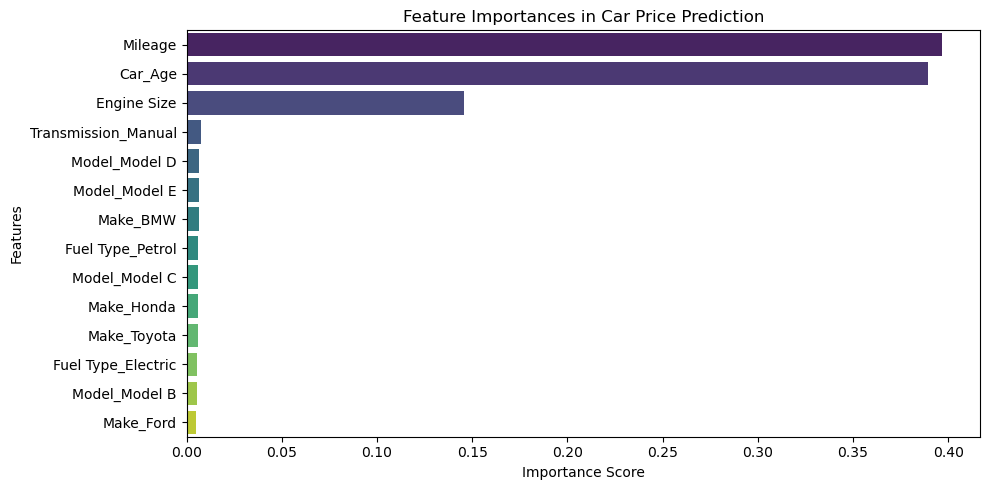

In [23]:
importances = rf_model.feature_importances_
features_df = pd.DataFrame(
    {"Feature": X_encoded.columns, "Importance": importances}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=features_df, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importances in Car Price Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()